In [1]:
# Импорт необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings

warnings.filterwarnings('ignore')

# Настройка отображения графиков
%matplotlib inline
plt.style.use('ggplot')
sns.set_palette("husl")

## 1. Загрузка и разбор данных

# Практическое занятие №5: Решение задачи регрессии

**Задание:** Разработка прототипа системы оценки стоимости домов для риэлтерского агентства (датасет California Housing).

**Целевая переменная:** `median_house_value` — медианная стоимость дома в районе.

In [2]:
# Загрузка из локального файла
df = pd.read_csv('housing.csv')

print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")
print(f"\nПервые 5 строк данных:")
print(df.head())
print(f"\nИнформация о данных:")
print(df.info())
print(f"\nСтатистическое описание:")
print(df.describe())

Размер датасета: 20640 строк, 10 столбцов

Первые 5 строк данных:
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  

Информац

### Проверка пропущенных значений

В столбце `total_bedrooms` есть 207 пропусков. Удаляем строки с пропусками (менее 1% от датасета).

In [3]:
# Проверка на пропущенные значения
print(f"\nПропущенные значения:")
print(df.isnull().sum())

# Удаляем строки с пропущенными значениями (если есть)
df = df.dropna()
print(f"\nПосле удаления пропусков: {df.shape}")


Пропущенные значения:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

После удаления пропусков: (20433, 10)


## 2. Исследование целевой переменной

Целевая переменная — `median_house_value` (медианная стоимость дома в районе).

**Важно:** в датасете California Housing значения обрезаны сверху на уровне $500,001 — это искусственный потолок, который влияет на качество модели.

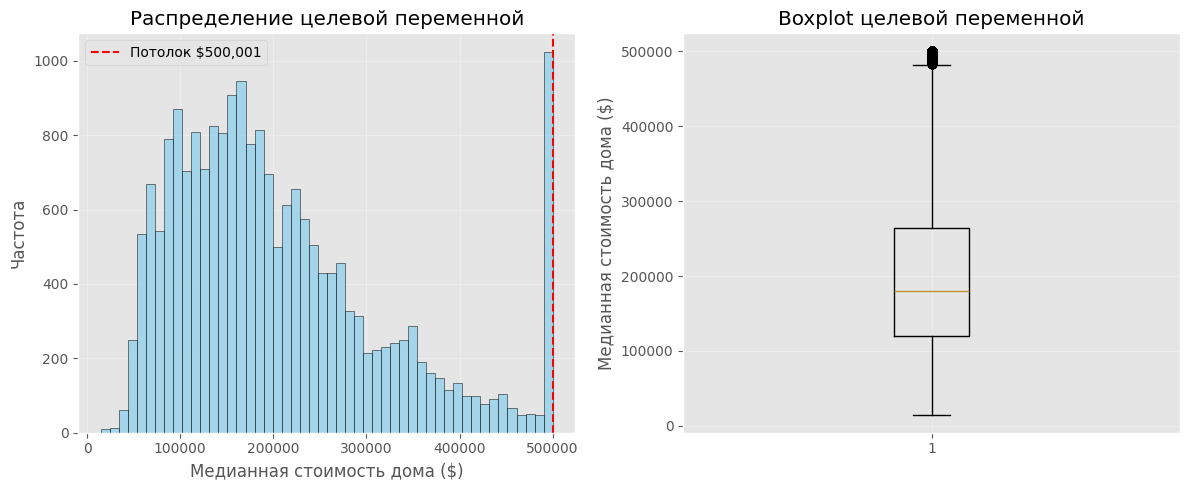

Статистика целевой переменной:
  Среднее: $206,864
  Медиана: $179,700
  Мин:     $14,999
  Макс:    $500,001
  Стд. откл.: $115,436

  Записей с потолком $500,001: 958 (4.7% от выборки)


In [4]:
# Целевая переменная: median_house_value (медианная стоимость дома)
target = 'median_house_value'

# Построение гистограммы целевой переменной
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df[target], bins=50, edgecolor='black', alpha=0.7, color='skyblue')
plt.xlabel('Медианная стоимость дома ($)')
plt.ylabel('Частота')
plt.title('Распределение целевой переменной')
plt.axvline(x=500001, color='red', linestyle='--', linewidth=1.5, label='Потолок $500,001')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.boxplot(df[target])
plt.ylabel('Медианная стоимость дома ($)')
plt.title('Boxplot целевой переменной')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Статистика целевой переменной:")
print(f"  Среднее: ${df[target].mean():,.0f}")
print(f"  Медиана: ${df[target].median():,.0f}")
print(f"  Мин:     ${df[target].min():,.0f}")
print(f"  Макс:    ${df[target].max():,.0f}")
print(f"  Стд. откл.: ${df[target].std():,.0f}")
print(f"\n  Записей с потолком $500,001: {(df[target] >= 500001).sum()} "
      f"({(df[target] >= 500001).mean()*100:.1f}% от выборки)")

## 3. Выбор признаков и визуализация связи

Выбираем 3 наиболее понятных признака для прогнозирования стоимости:
1. **`median_income`** — медианный доход в районе (в десятках тысяч $). Главный драйвер цены.
2. **`housing_median_age`** — медианный возраст домов в районе (в годах).
3. **`rooms_per_household`** — среднее число комнат на домохозяйство (производный признак: `total_rooms / households`).


3. ВЫБОР ПРИЗНАКОВ И ВИЗУАЛИЗАЦИЯ СВЯЗИ


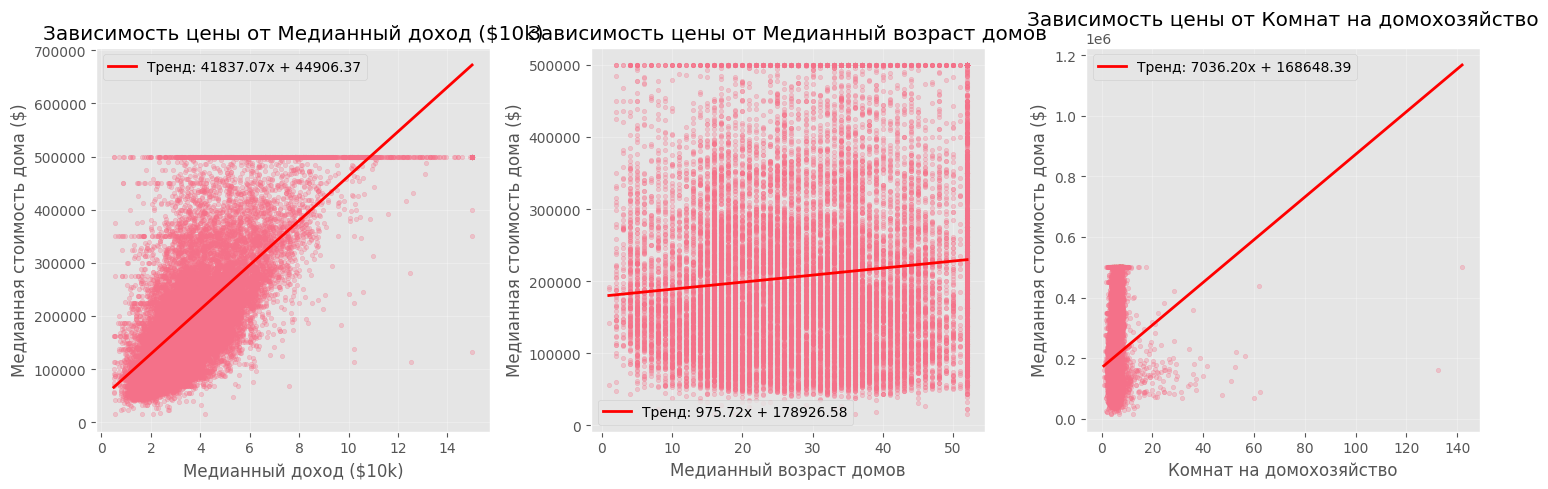

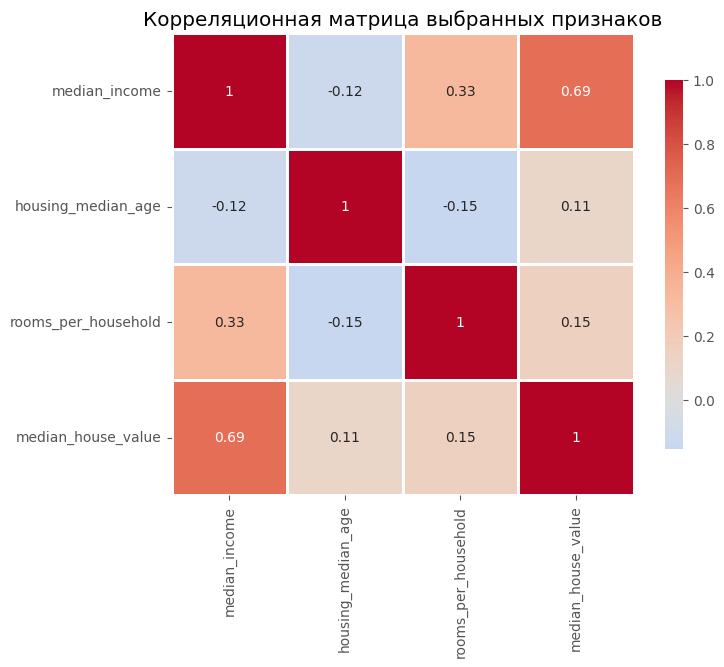

Корреляция признаков с целевой переменной:
median_income: 0.688
housing_median_age: 0.106
rooms_per_household: 0.151


In [5]:
# 3. ВЫБОР ПРИЗНАКОВ И ВИЗУАЛИЗАЦИЯ СВЯЗИ
print("\n" + "=" * 60)
print("3. ВЫБОР ПРИЗНАКОВ И ВИЗУАЛИЗАЦИЯ СВЯЗИ")
print("=" * 60)

# Выбираем 3 наиболее понятных признака:
# 1. median_income - медианный доход в районе
# 2. housing_median_age - медианный возраст домов
# 3. total_rooms - общее количество комнат (нормируем на количество домохозяйств)
# Создаем признак rooms_per_household (комнат на домохозяйство)
df['rooms_per_household'] = df['total_rooms'] / df['households']

selected_features = ['median_income', 'housing_median_age', 'rooms_per_household']
feature_names = ['Медианный доход ($10k)', 'Медианный возраст домов', 'Комнат на домохозяйство']

# Визуализация связи выбранных признаков с целевой переменной
plt.figure(figsize=(15, 5))

for i, (feature, name) in enumerate(zip(selected_features, feature_names)):
    plt.subplot(1, 3, i + 1)
    plt.scatter(df[feature], df[target], alpha=0.3, s=10)
    plt.xlabel(name)
    plt.ylabel('Медианная стоимость дома ($)')
    plt.title(f'Зависимость цены от {name}')

    # Добавляем линию тренда
    z = np.polyfit(df[feature], df[target], 1)
    p = np.poly1d(z)
    plt.plot(df[feature].sort_values(),
             p(df[feature].sort_values()),
             "r-", linewidth=2, label=f'Тренд: {z[0]:.2f}x + {z[1]:.2f}')
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Корреляционная матрица
plt.figure(figsize=(8, 6))
corr_matrix = df[selected_features + [target]].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Корреляционная матрица выбранных признаков')
plt.show()

print("Корреляция признаков с целевой переменной:")
for feature in selected_features:
    corr = df[feature].corr(df[target])
    print(f"{feature}: {corr:.3f}")

## 4. Обучение и оценка линейной модели

Обучаем `LinearRegression` на выбранных 3 признаках. Метрики:
- **MAE** — средняя абсолютная ошибка (в долларах)
- **MSE** — средняя квадратичная ошибка (штрафует большие ошибки сильнее)
- **R2** — коэффициент детерминации (какую долю дисперсии объясняет модель; 1.0 = идеал)

In [6]:
# Подготовка данных
X = df[selected_features]
y = df[target]

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

# Обучение линейной регрессии
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Предсказания
y_pred_lr = lr_model.predict(X_test)

# Метрики для линейной модели
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("\nМетрики линейной регрессии:")
print(f"  MAE (средняя абсолютная ошибка): ${mae_lr:,.0f}")
print(f"  MSE (средняя квадратичная ошибка): ${mse_lr:,.0f}")
print(f"  RMSE (корень из MSE): ${np.sqrt(mse_lr):,.0f}")
print(f"  R2 (коэффициент детерминации): {r2_lr:.4f}")
print(f"  → Модель объясняет {r2_lr*100:.1f}% дисперсии цены")

# Интерпретация коэффициентов
print("\n" + "=" * 60)
print("ИНТЕРПРЕТАЦИЯ КОЭФФИЦИЕНТОВ")
print("=" * 60)

print("\nКоэффициенты модели (model.coef_):")
for feature, coef in zip(selected_features, lr_model.coef_):
    print(f"  {feature}: {coef:.2f}")
print(f"  Свободный член (intercept): {lr_model.intercept_:.2f}")

print("\nИнтерпретация для бизнес-заказчика:")

coef_income = lr_model.coef_[0]
print(f"1. median_income (медианный доход):")
print(f"   Увеличение медианного дохода в районе на $10,000 приводит к росту")
print(f"   прогнозируемой стоимости дома в среднем на ${coef_income:,.0f}")

coef_age = lr_model.coef_[1]
direction_age = "росту" if coef_age > 0 else "снижению"
print(f"\n2. housing_median_age (возраст домов):")
print(f"   Увеличение медианного возраста домов на 1 год приводит к")
print(f"   {direction_age} прогнозируемой стоимости в среднем на ${abs(coef_age):,.0f}")

coef_rooms = lr_model.coef_[2]
direction_rooms = "росту" if coef_rooms > 0 else "снижению"
print(f"\n3. rooms_per_household (комнат на домохозяйство):")
print(f"   Увеличение количества комнат на домохозяйство на 1 приводит к")
print(f"   {direction_rooms} прогнозируемой стоимости в среднем на ${abs(coef_rooms):,.0f}")
if coef_rooms < 0:
    print(f"   (Отрицательный коэффициент может объясняться тем, что большие дома")
    print(f"    чаще расположены в удалённых районах с более низкими ценами)")

Размер обучающей выборки: (16346, 3)
Размер тестовой выборки: (4087, 3)

Метрики линейной регрессии:
  MAE (средняя абсолютная ошибка): $60,925
  MSE (средняя квадратичная ошибка): $6,665,145,554
  RMSE (корень из MSE): $81,640
  R2 (коэффициент детерминации): 0.5126
  → Модель объясняет 51.3% дисперсии цены

ИНТЕРПРЕТАЦИЯ КОЭФФИЦИЕНТОВ

Коэффициенты модели (model.coef_):
  median_income: 44230.69
  housing_median_age: 1675.39
  rooms_per_household: -2715.35
  Свободный член (intercept): 2230.11

Интерпретация для бизнес-заказчика:
1. median_income (медианный доход):
   Увеличение медианного дохода в районе на $10,000 приводит к росту
   прогнозируемой стоимости дома в среднем на $44,231

2. housing_median_age (возраст домов):
   Увеличение медианного возраста домов на 1 год приводит к
   росту прогнозируемой стоимости в среднем на $1,675

3. rooms_per_household (комнат на домохозяйство):
   Увеличение количества комнат на домохозяйство на 1 приводит к
   снижению прогнозируемой стоимо

## 5. Сравнение с нелинейной моделью

Обучаем `DecisionTreeRegressor(max_depth=3)` — нелинейная модель, которая разбивает пространство признаков на прямоугольные области и предсказывает среднее значение в каждой. `max_depth=3` ограничивает глубину дерева для предотвращения переобучения.

In [7]:
# 5. СРАВНЕНИЕ С ДЕРЕВОМ РЕШЕНИЙ
print("\n" + "=" * 60)
print("5. СРАВНЕНИЕ С НЕЛИНЕЙНОЙ МОДЕЛЬЮ (ДЕРЕВО РЕШЕНИЙ)")
print("=" * 60)

# Обучение дерева решений
dt_model = DecisionTreeRegressor(max_depth=3, random_state=42)
dt_model.fit(X_train, y_train)

# Предсказания
y_pred_dt = dt_model.predict(X_test)

# Метрики для дерева решений
mae_dt = mean_absolute_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("Метрики дерева решений (max_depth=3):")
print(f"MAE: ${mae_dt:.2f}")
print(f"R2: {r2_dt:.4f}")

print("\n" + "=" * 60)
print("СРАВНЕНИЕ МОДЕЛЕЙ")
print("=" * 60)

print(f"{'Модель':<20} {'MAE ($)':<15} {'R2':<10}")
print("-" * 45)
print(f"{'Linear Regression':<20} {mae_lr:<15.2f} {r2_lr:<10.4f}")
print(f"{'Decision Tree':<20} {mae_dt:<15.2f} {r2_dt:<10.4f}")

# Определяем лучшую модель
if mae_dt < mae_lr:
    best_model = "Дерево решений"
    best_pred = y_pred_dt
    best_mae = mae_dt
    best_r2 = r2_dt
else:
    best_model = "Линейная регрессия"
    best_pred = y_pred_lr
    best_mae = mae_lr
    best_r2 = r2_lr

print(f"\nЛучшая модель: {best_model}")
print(f"  MAE: ${best_mae:.2f}")
print(f"  R2: {best_r2:.4f}")


5. СРАВНЕНИЕ С НЕЛИНЕЙНОЙ МОДЕЛЬЮ (ДЕРЕВО РЕШЕНИЙ)
Метрики дерева решений (max_depth=3):
MAE: $62436.20
R2: 0.4885

СРАВНЕНИЕ МОДЕЛЕЙ
Модель               MAE ($)         R2        
---------------------------------------------
Linear Regression    60924.99        0.5126    
Decision Tree        62436.20        0.4885    

Лучшая модель: Линейная регрессия
  MAE: $60924.99
  R2: 0.5126


## 6. Визуализация предсказаний лучшей модели

Scatter plot: реальные значения (ось X) vs предсказанные (ось Y). Идеальная модель дала бы все точки на прямой y=x.


6. ВИЗУАЛИЗАЦИЯ ПРЕДСКАЗАНИЙ ЛУЧШЕЙ МОДЕЛИ


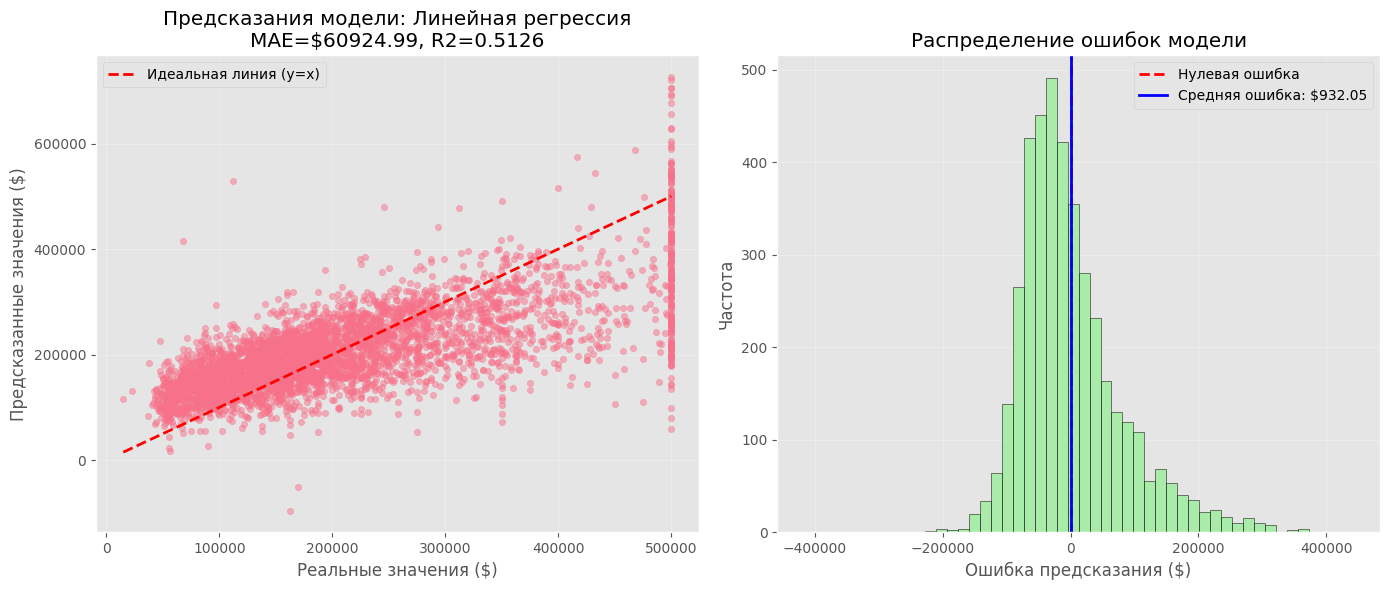

Статистика ошибок:
Средняя ошибка: $932.05
Медианная ошибка: $-16951.16
Стандартное отклонение ошибок: $81645.01
Минимальная ошибка: $-416137.67
Максимальная ошибка: $441451.59


In [8]:
# 6. ВИЗУАЛИЗАЦИЯ ПРЕДСКАЗАНИЙ ЛУЧШЕЙ МОДЕЛИ
print("\n" + "=" * 60)
print("6. ВИЗУАЛИЗАЦИЯ ПРЕДСКАЗАНИЙ ЛУЧШЕЙ МОДЕЛИ")
print("=" * 60)

plt.figure(figsize=(14, 6))

# Scatter plot предсказанных vs реальных значений
plt.subplot(1, 2, 1)
plt.scatter(y_test, best_pred, alpha=0.5, s=20)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Идеальная линия (y=x)')
plt.xlabel('Реальные значения ($)')
plt.ylabel('Предсказанные значения ($)')
plt.title(f'Предсказания модели: {best_model}\nMAE=${best_mae:.2f}, R2={best_r2:.4f}')
plt.legend()
plt.grid(True, alpha=0.3)

# Гистограмма ошибок
plt.subplot(1, 2, 2)
errors = y_test - best_pred
plt.hist(errors, bins=50, edgecolor='black', alpha=0.7, color='lightgreen')
plt.xlabel('Ошибка предсказания ($)')
plt.ylabel('Частота')
plt.title('Распределение ошибок модели')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Нулевая ошибка')
plt.axvline(x=errors.mean(), color='blue', linestyle='-', linewidth=2,
            label=f'Средняя ошибка: ${errors.mean():.2f}')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Статистика ошибок:")
print(f"Средняя ошибка: ${errors.mean():.2f}")
print(f"Медианная ошибка: ${np.median(errors):.2f}")
print(f"Стандартное отклонение ошибок: ${errors.std():.2f}")
print(f"Минимальная ошибка: ${errors.min():.2f}")
print(f"Максимальная ошибка: ${errors.max():.2f}")


## 7. Важность признаков и выводы


ВАЖНОСТЬ ПРИЗНАКОВ (ДЕРЕВО РЕШЕНИЙ)
               feature  importance
0        median_income    0.913740
1   housing_median_age    0.057048
2  rooms_per_household    0.029212


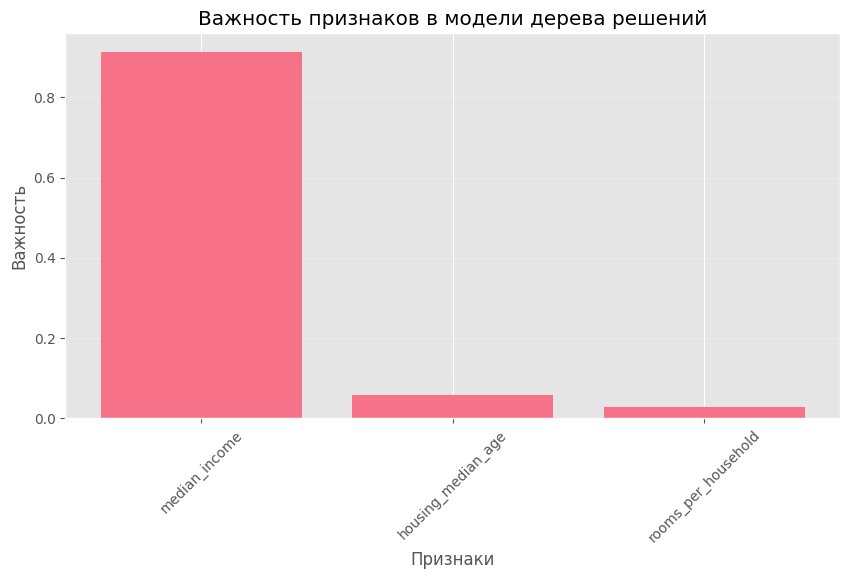


ВЫВОДЫ
1. Линейная модель показывает R2 = 0.5126, что означает, что она объясняет 51.3% дисперсии целевой переменной
2. Дерево решений показывает R2 = 0.4885, что хуже линейной модели
3. Наиболее важный признак: median_income (важность: 0.914)
4. Точки на графике предсказаний достаточно близки к идеальной линии, но есть выбросы
5. Для улучшения модели можно добавить больше признаков или использовать более сложные алгоритмы


In [9]:
# Дополнительно: важность признаков для дерева решений
print("\n" + "=" * 60)
print("ВАЖНОСТЬ ПРИЗНАКОВ (ДЕРЕВО РЕШЕНИЙ)")
print("=" * 60)

feature_importance = pd.DataFrame({
    'feature': selected_features,
    'importance': dt_model.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance)

plt.figure(figsize=(10, 5))
plt.bar(feature_importance['feature'], feature_importance['importance'])
plt.xlabel('Признаки')
plt.ylabel('Важность')
plt.title('Важность признаков в модели дерева решений')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')
plt.show()

print("\n" + "=" * 60)
print("ВЫВОДЫ")
print("=" * 60)
print(
    f"1. Линейная модель показывает R2 = {r2_lr:.4f}, что означает, что она объясняет {r2_lr * 100:.1f}% дисперсии целевой переменной")
print(f"2. Дерево решений показывает R2 = {r2_dt:.4f}, что {'лучше' if r2_dt > r2_lr else 'хуже'} линейной модели")
print(f"3. Наиболее важный признак: {feature_importance.iloc[0, 0]} (важность: {feature_importance.iloc[0, 1]:.3f})")
print("4. Точки на графике предсказаний достаточно близки к идеальной линии, но есть выбросы")
print("5. Для улучшения модели можно добавить больше признаков или использовать более сложные алгоритмы")